In [13]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
import torch

In [14]:
data = pd.read_csv("../../data/processed/model_df.csv")

In [15]:
data

,patient_id,visit_date,mmse,cdr_global,cdr_memory,cdr_orientation,cdr_judgment,cdr_community,cdr_home_hobbies,cdr_personal_care,...,blood_date,hdl,vldl,ldl,total_cholesterol,triglyceride,fasting_glucose,hba1c,days_since_blood,has_recent_blood
0,9,2003-12-24,18.0,1.0,1.0,1.0,1.0,1.0,0.5,0.0,...,2003-12-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1
1,9,2004-12-20,10.0,1.0,1.0,1.0,1.0,1.0,0.5,0.0,...,2003-12-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,362.0,1
2,9,2005-01-17,16.0,1.0,1.0,1.0,1.0,1.0,0.5,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,9,2005-10-17,10.0,1.0,1.0,1.0,1.0,1.0,0.5,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,9,2006-04-11,12.0,1.0,1.0,1.0,1.0,1.0,0.5,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3188,1128,2024-04-19,28.0,0.5,0.5,0.0,0.0,0.0,0.0,0.0,...,2024-04-16,45.0,19.0,96.0,160.0,93.0,126.0,6.0,3.0,1
3189,1124,2024-04-25,24.0,0.5,0.5,0.0,0.0,0.0,0.0,0.0,...,2024-03-23,61.0,29.0,99.0,189.0,145.0,163.0,7.3,33.0,1
3190,382,2024-05-03,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,...,2024-02-15,42.0,19.0,115.0,176.0,95.0,126.0,6.0,78.0,1
3191,141,2024-05-06,23.0,1.0,1.0,0.5,1.0,1.0,1.0,1.0,...,2024-02-24,31.0,29.0,106.0,166.0,143.0,134.0,6.3,72.0,1


In [16]:
data.columns

Index(['patient_id', 'visit_date', 'mmse', 'cdr_global', 'cdr_memory',
       'cdr_orientation', 'cdr_judgment', 'cdr_community', 'cdr_home_hobbies',
       'cdr_personal_care', 'cdr_sob', 'target_date', 'target_mmse_1y',
       'target_followup_days', 'previous_mmse', 'previous_visit_date',
       'mmse_change_prev', 'days_since_prev_mmse', 'diagnosis', 'bio_category',
       'gender', 'age_first_mmse', 'education', 'hypertension', 'diabetes',
       'hyperlipidemia', 'apoe_clean', 'apoe4_count', 'apoe4_carrier',
       'age_onset', 'disease_duration_at_baseline', 'casi_date',
       'casi_mental_manipulation', 'casi_attention', 'casi_orientation',
       'casi_long_term_memory', 'casi_short_term_memory', 'casi_abstraction',
       'casi_drawing', 'casi_verbal_fluency', 'casi_language', 'casi_total',
       'days_since_casi', 'has_recent_casi', 'blood_date', 'hdl', 'vldl',
       'ldl', 'total_cholesterol', 'triglyceride', 'fasting_glucose', 'hba1c',
       'days_since_blood', 'has_re

### LSTM-NARX

In [17]:
# ============================================================
# 1. Import
# ============================================================
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
SEED = 42

cuda


In [18]:
data["visit_date"] = pd.to_datetime(
    data["visit_date"],
    errors="coerce"
)

data["target_date"] = pd.to_datetime(
    data["target_date"],
    errors="coerce"
)

data = (
    data
    .sort_values(["patient_id", "visit_date"])
    .reset_index(drop=True)
)

print(data.shape)
data.head()

(3193, 54)


,patient_id,visit_date,mmse,cdr_global,cdr_memory,cdr_orientation,cdr_judgment,cdr_community,cdr_home_hobbies,cdr_personal_care,...,blood_date,hdl,vldl,ldl,total_cholesterol,triglyceride,fasting_glucose,hba1c,days_since_blood,has_recent_blood
0,1,2006-11-13,17.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1,2007-08-31,15.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2006-11-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,290.0,1
2,1,2008-01-31,15.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2008-01-04,73.0,NaN,83.0,178.0,108.0,NaN,NaN,27.0,1
3,1,2008-08-14,16.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,2008-01-04,73.0,NaN,83.0,178.0,108.0,NaN,NaN,223.0,1
4,1,2009-02-05,17.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [19]:
# 由於blood資料缺失值較多，先不放
target_col = "target_mmse_1y"

exog_features = [
    # CDR
    "cdr_global",
    "cdr_memory",
    "cdr_orientation",
    "cdr_judgment",
    "cdr_community",
    "cdr_home_hobbies",
    "cdr_personal_care",
    "cdr_sob",

    # demographic / clinical
    "gender",
    "age_first_mmse",
    "education",
    "hypertension",
    "diabetes",
    "hyperlipidemia",

    # APOE
    "apoe4_carrier",

    # CASI
    "casi_mental_manipulation",
    "casi_attention",
    "casi_orientation",
    "casi_long_term_memory",
    "casi_short_term_memory",
    "casi_abstraction",
    "casi_drawing",
    "casi_verbal_fluency",
    "casi_language",
    "casi_total",

    "days_since_casi",
    "has_recent_casi",
]

In [20]:
missing_cols = [
    col
    for col in exog_features + [target_col]
    if col not in data.columns
]

print("不存在欄位:", missing_cols)

不存在欄位: []


In [21]:
#只保留有 target 的 index visits
model_data = data[
    data[target_col].notna()
].copy()

print("samples:", len(model_data))
print("patients:", model_data["patient_id"].nunique())

samples: 3193
patients: 723


In [22]:
# Patient-level split
patient_ids = model_data[
    "patient_id"
].unique()

train_patients, temp_patients = train_test_split(
    patient_ids,
    test_size=0.30,
    random_state=SEED
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED
)

print("Train patients:", len(train_patients))
print("Val patients:", len(val_patients))
print("Test patients:", len(test_patients))

Train patients: 506
Val patients: 108
Test patients: 109


In [23]:
#確認沒有patient leakage
print(
    len(set(train_patients) & set(val_patients)),
    len(set(train_patients) & set(test_patients)),
    len(set(val_patients) & set(test_patients))
)

0 0 0


In [24]:
#對每一筆樣本，抓出這個病人在該次門診以前的 MMSE 歷史，
# 最多保留最近 7 次，當作輸入序列；再把這筆樣本對應的 1 年後 MMSE 當成預測目標。
MAX_LEN = 7

def build_sequences(
    full_data,
    sample_data,
    exog_features,
    max_len=7
):
    sequences = []
    sequence_lengths = []

    exogs = []
    targets = []

    patient_list = []
    index_dates = []

    patient_history = {
        pid: g.sort_values("visit_date").copy()
        for pid, g in full_data.groupby("patient_id")
    }

    for _, row in sample_data.iterrows():

        pid = row["patient_id"]
        index_date = row["visit_date"]

        history = patient_history[pid]

        history = history[
            history["visit_date"] <= index_date
        ]

        mmse_history = (
            history["mmse"]
            .dropna()
            .values
            .astype(float)
        )

        if len(mmse_history) == 0:
            continue

        mmse_history = mmse_history[-max_len:]

        sequences.append(mmse_history)
        sequence_lengths.append(
            len(mmse_history)
        )

        exogs.append(
            row[exog_features].values
        )

        targets.append(
            row["target_mmse_1y"]
        )

        patient_list.append(pid)
        index_dates.append(index_date)

    return (
        sequences,
        np.array(sequence_lengths),
        np.array(exogs, dtype=object),
        np.array(targets, dtype=float),
        np.array(patient_list),
        np.array(index_dates)
    )

#建立 train / val / test sample
train_samples = model_data[
    model_data["patient_id"].isin(train_patients)
].copy()

val_samples = model_data[
    model_data["patient_id"].isin(val_patients)
].copy()

test_samples = model_data[
    model_data["patient_id"].isin(test_patients)
].copy()

(
    train_seq_raw,
    train_lengths,
    X_train_exog_raw,
    y_train,
    train_pid,
    train_dates
) = build_sequences(
    data,
    train_samples,
    exog_features,
    MAX_LEN
)

(
    val_seq_raw,
    val_lengths,
    X_val_exog_raw,
    y_val,
    val_pid,
    val_dates
) = build_sequences(
    data,
    val_samples,
    exog_features,
    MAX_LEN
)

(
    test_seq_raw,
    test_lengths,
    X_test_exog_raw,
    y_test,
    test_pid,
    test_dates
) = build_sequences(
    data,
    test_samples,
    exog_features,
    MAX_LEN
)

print("train:", len(train_seq_raw))
print("val:", len(val_seq_raw))
print("test:", len(test_seq_raw))

train: 2171
val: 518
test: 504


In [25]:
#Impute exogenous features
#血液目前沒放，所以這裡只處理 clinical/CASI。

X_train_exog_raw = X_train_exog_raw.astype(float)
X_val_exog_raw = X_val_exog_raw.astype(float)
X_test_exog_raw = X_test_exog_raw.astype(float)

exog_imputer = SimpleImputer(
    strategy="median"
)

X_train_exog = exog_imputer.fit_transform(
    X_train_exog_raw
)

X_val_exog = exog_imputer.transform(
    X_val_exog_raw
)

X_test_exog = exog_imputer.transform(
    X_test_exog_raw
)


#Standardize exogenous features

exog_scaler = StandardScaler()

X_train_exog = exog_scaler.fit_transform(
    X_train_exog
)

X_val_exog = exog_scaler.transform(
    X_val_exog
)

X_test_exog = exog_scaler.transform(
    X_test_exog
)

#Standardize MMSE sequences
train_mmse_values = np.concatenate(
    train_seq_raw
).reshape(-1, 1)

mmse_scaler = StandardScaler()

mmse_scaler.fit(
    train_mmse_values
)

,copy,True
,with_mean,True
,with_std,True


In [26]:
def scale_and_pad_sequences(
    sequences,
    scaler,
    max_len=7
):
    X = np.zeros(
        (len(sequences), max_len, 1),
        dtype=np.float32
    )

    lengths = []

    for i, seq in enumerate(sequences):

        seq = np.asarray(
            seq,
            dtype=float
        ).reshape(-1, 1)

        seq_scaled = (
            scaler
            .transform(seq)
            .flatten()
        )

        length = len(seq_scaled)

        X[
            i,
            :length,
            0
        ] = seq_scaled

        lengths.append(length)

    return (
        X,
        np.array(lengths)
    )

X_train_seq, train_lengths = \
    scale_and_pad_sequences(
        train_seq_raw,
        mmse_scaler,
        MAX_LEN
    )

X_val_seq, val_lengths = \
    scale_and_pad_sequences(
        val_seq_raw,
        mmse_scaler,
        MAX_LEN
    )

X_test_seq, test_lengths = \
    scale_and_pad_sequences(
        test_seq_raw,
        mmse_scaler,
        MAX_LEN
    )

In [27]:
#Standardize target

y_scaler = StandardScaler()

y_train_scaled = (
    y_scaler
    .fit_transform(
        y_train.reshape(-1, 1)
    )
    .flatten()
)

y_val_scaled = (
    y_scaler
    .transform(
        y_val.reshape(-1, 1)
    )
    .flatten()
)

y_test_scaled = (
    y_scaler
    .transform(
        y_test.reshape(-1, 1)
    )
    .flatten()
)

In [28]:
#建立 PyTorch Dataset

class MMSEDataset(Dataset):

    def __init__(
        self,
        X_seq,
        lengths,
        X_exog,
        y
    ):
        self.X_seq = torch.tensor(
            X_seq,
            dtype=torch.float32
        )

        self.lengths = torch.tensor(
            lengths,
            dtype=torch.long
        )

        self.X_exog = torch.tensor(
            X_exog,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X_seq[idx],
            self.lengths[idx],
            self.X_exog[idx],
            self.y[idx]
        )

In [29]:
#DataLoader

BATCH_SIZE = 32

train_dataset = MMSEDataset(
    X_train_seq,
    train_lengths,
    X_train_exog,
    y_train_scaled
)

val_dataset = MMSEDataset(
    X_val_seq,
    val_lengths,
    X_val_exog,
    y_val_scaled
)

test_dataset = MMSEDataset(
    X_test_seq,
    test_lengths,
    X_test_exog,
    y_test_scaled
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [30]:
#LSTM-NARX model

class LSTMNARX(nn.Module):

    def __init__(
        self,
        exog_dim,
        lstm_hidden=32,
        exog_hidden=32,
        fusion_hidden=32,
        dropout=0.2
    ):
        super().__init__()

        # --------------------------------------
        # MMSE autoregressive branch
        # --------------------------------------
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=lstm_hidden,
            batch_first=True
        )

        self.seq_dropout = nn.Dropout(
            dropout
        )

        # --------------------------------------
        # Exogenous branch
        # --------------------------------------
        self.exog_net = nn.Sequential(
            nn.Linear(
                exog_dim,
                exog_hidden
            ),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # --------------------------------------
        # Fusion
        # --------------------------------------
        self.fusion = nn.Sequential(
            nn.Linear(
                lstm_hidden + exog_hidden,
                fusion_hidden
            ),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(
                fusion_hidden,
                1
            )
        )

    def forward(
        self,
        x_seq,
        lengths,
        x_exog
    ):

        # pack padded sequence
        packed = nn.utils.rnn.pack_padded_sequence(
            x_seq,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (h_n, _) = self.lstm(
            packed
        )

        # final hidden state
        seq_feat = h_n[-1]

        seq_feat = self.seq_dropout(
            seq_feat
        )

        # exogenous branch
        exog_feat = self.exog_net(
            x_exog
        )

        # concatenate
        fused = torch.cat(
            [
                seq_feat,
                exog_feat
            ],
            dim=1
        )

        output = self.fusion(
            fused
        )

        return output.squeeze(1)

# 初始化
model = LSTMNARX(
    exog_dim=X_train_exog.shape[1],
    lstm_hidden=32,
    exog_hidden=32,
    fusion_hidden=32,
    dropout=0.2
).to(device)

print(model)

LSTMNARX(
  (lstm): LSTM(1, 32, batch_first=True)
  (seq_dropout): Dropout(p=0.2, inplace=False)
  (exog_net): Sequential(
    (0): Linear(in_features=27, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (fusion): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [31]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    total_loss = 0.0

    for (
        x_seq,
        lengths,
        x_exog,
        y
    ) in loader:

        x_seq = x_seq.to(device)
        lengths = lengths.to(device)
        x_exog = x_exog.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(
            x_seq,
            lengths,
            x_exog
        )

        loss = criterion(
            pred,
            y
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * len(y)
        )

    return (
        total_loss
        / len(loader.dataset)
    )

def evaluate_loss(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for (
            x_seq,
            lengths,
            x_exog,
            y
        ) in loader:

            x_seq = x_seq.to(device)
            lengths = lengths.to(device)
            x_exog = x_exog.to(device)
            y = y.to(device)

            pred = model(
                x_seq,
                lengths,
                x_exog
            )

            loss = criterion(
                pred,
                y
            )

            total_loss += (
                loss.item()
                * len(y)
            )

    return (
        total_loss
        / len(loader.dataset)
    )

In [32]:
#Early stopping training loop

MAX_EPOCHS = 100
PATIENCE = 10

best_val_loss = np.inf
best_state = None

patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss = evaluate_loss(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }

        patience_counter = 0

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:
            print(
                "Early stopping."
            )
            break

model.load_state_dict(
    best_state
)

model = model.to(device)

Epoch 001 | Train Loss: 0.4728 | Val Loss: 0.1556
Epoch 002 | Train Loss: 0.2210 | Val Loss: 0.1426
Epoch 003 | Train Loss: 0.1988 | Val Loss: 0.1321
Epoch 004 | Train Loss: 0.1797 | Val Loss: 0.1225
Epoch 005 | Train Loss: 0.1726 | Val Loss: 0.1240
Epoch 006 | Train Loss: 0.1636 | Val Loss: 0.1200
Epoch 007 | Train Loss: 0.1624 | Val Loss: 0.1176
Epoch 008 | Train Loss: 0.1567 | Val Loss: 0.1210
Epoch 009 | Train Loss: 0.1553 | Val Loss: 0.1178
Epoch 010 | Train Loss: 0.1550 | Val Loss: 0.1152
Epoch 011 | Train Loss: 0.1522 | Val Loss: 0.1144
Epoch 012 | Train Loss: 0.1541 | Val Loss: 0.1137
Epoch 013 | Train Loss: 0.1481 | Val Loss: 0.1131
Epoch 014 | Train Loss: 0.1497 | Val Loss: 0.1136
Epoch 015 | Train Loss: 0.1509 | Val Loss: 0.1128
Epoch 016 | Train Loss: 0.1495 | Val Loss: 0.1198
Epoch 017 | Train Loss: 0.1439 | Val Loss: 0.1140
Epoch 018 | Train Loss: 0.1449 | Val Loss: 0.1160
Epoch 019 | Train Loss: 0.1491 | Val Loss: 0.1152
Epoch 020 | Train Loss: 0.1481 | Val Loss: 0.1163


In [33]:
def predict_model(
    model,
    loader,
    device
):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for (
            x_seq,
            lengths,
            x_exog,
            y
        ) in loader:

            x_seq = x_seq.to(device)
            lengths = lengths.to(device)
            x_exog = x_exog.to(device)

            pred = model(
                x_seq,
                lengths,
                x_exog
            )

            preds.extend(
                pred.cpu().numpy()
            )

            targets.extend(
                y.numpy()
            )

    return (
        np.array(preds),
        np.array(targets)
    )

y_pred_scaled, _ = predict_model(
    model,
    test_loader,
    device
)

#反標準化
y_pred = (
    y_scaler
    .inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    )
    .flatten()
)

In [34]:
#評估

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

bias = np.mean(
    y_pred - y_test
)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")
print(f"Bias : {bias:.4f}")

RMSE : 2.4083
MAE  : 1.7110
R²   : 0.9038
Bias : 0.1502


In [35]:
result_df = pd.DataFrame({
    "patient_id": test_pid,
    "index_date": test_dates,
    "true_mmse_1y": y_test,
    "pred_mmse_1y": y_pred
})

result_df["error"] = (
    result_df["pred_mmse_1y"]
    - result_df["true_mmse_1y"]
)

result_df.head()

,patient_id,index_date,true_mmse_1y,pred_mmse_1y,error
0,8,2006-09-22,24.0,25.704075,1.704075
1,8,2007-09-12,25.0,24.375570,-0.624430
2,8,2008-04-21,25.0,26.296040,1.296040
3,8,2008-07-15,26.0,24.841808,-1.158192
4,8,2009-02-19,26.0,24.381144,-1.618856


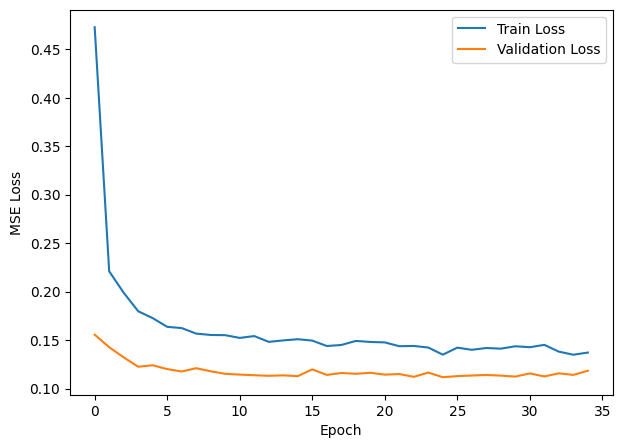

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

### xgboost

In [40]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np
import pandas as pd

In [41]:
xgb_features = [
    # Current + longitudinal MMSE
    "mmse",
    "previous_mmse",
    "mmse_change_prev",
    "days_since_prev_mmse",

    # CDR
    "cdr_global",
    "cdr_memory",
    "cdr_orientation",
    "cdr_judgment",
    "cdr_community",
    "cdr_home_hobbies",
    "cdr_personal_care",
    "cdr_sob",

    # Demographic / clinical
    "gender",
    "age_first_mmse",
    "education",
    "hypertension",
    "diabetes",
    "hyperlipidemia",

    # APOE
    "apoe4_carrier",

    # CASI
    "casi_mental_manipulation",
    "casi_attention",
    "casi_orientation",
    "casi_long_term_memory",
    "casi_short_term_memory",
    "casi_abstraction",
    "casi_drawing",
    "casi_verbal_fluency",
    "casi_language",
    "casi_total",

    "days_since_casi",
    "has_recent_casi",
]

target_col = "target_mmse_1y"

In [43]:
xgb_train = model_data[
    model_data["patient_id"].isin(train_patients)
].copy()

xgb_val = model_data[
    model_data["patient_id"].isin(val_patients)
].copy()

xgb_test = model_data[
    model_data["patient_id"].isin(test_patients)
].copy()

In [44]:
X_train_xgb = xgb_train[xgb_features].copy()
y_train_xgb = xgb_train[target_col].copy()

X_val_xgb = xgb_val[xgb_features].copy()
y_val_xgb = xgb_val[target_col].copy()

X_test_xgb = xgb_test[xgb_features].copy()
y_test_xgb = xgb_test[target_col].copy()

print("Train:", X_train_xgb.shape)
print("Val  :", X_val_xgb.shape)
print("Test :", X_test_xgb.shape)

print("\nPatients:")
print("Train:", xgb_train["patient_id"].nunique())
print("Val  :", xgb_val["patient_id"].nunique())
print("Test :", xgb_test["patient_id"].nunique())

Train: (2171, 31)
Val  : (518, 31)
Test : (504, 31)

Patients:
Train: 506
Val  : 108
Test : 109


In [45]:
X_train_xgb = X_train_xgb.apply(
    pd.to_numeric,
    errors="coerce"
)

X_val_xgb = X_val_xgb.apply(
    pd.to_numeric,
    errors="coerce"
)

X_test_xgb = X_test_xgb.apply(
    pd.to_numeric,
    errors="coerce"
)

pd.DataFrame({
    "missing_n": X_train_xgb.isna().sum(),
    "missing_rate": X_train_xgb.isna().mean()
}).sort_values(
    "missing_rate",
    ascending=False
)

,missing_n,missing_rate
previous_mmse,506,0.233072
mmse_change_prev,506,0.233072
days_since_prev_mmse,506,0.233072
casi_mental_manipulation,216,0.099493
days_since_casi,216,0.099493
casi_total,216,0.099493
casi_language,216,0.099493
casi_short_term_memory,216,0.099493
casi_abstraction,216,0.099493
casi_drawing,216,0.099493


In [47]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",

    n_estimators=1000,
    learning_rate=0.03,

    max_depth=4,
    min_child_weight=5,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=SEED,
    n_jobs=-1,

    eval_metric="rmse"
)

xgb_model.fit(
    X_train_xgb,
    y_train_xgb,

    eval_set=[
        (X_train_xgb, y_train_xgb),
        (X_val_xgb, y_val_xgb)
    ],

    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


In [48]:
y_pred_xgb = xgb_model.predict(
    X_test_xgb
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test_xgb,
        y_pred_xgb
    )
)

xgb_mae = mean_absolute_error(
    y_test_xgb,
    y_pred_xgb
)

xgb_r2 = r2_score(
    y_test_xgb,
    y_pred_xgb
)

xgb_bias = np.mean(
    y_pred_xgb - y_test_xgb
)

print(f"XGBoost RMSE : {xgb_rmse:.4f}")
print(f"XGBoost MAE  : {xgb_mae:.4f}")
print(f"XGBoost R²   : {xgb_r2:.4f}")
print(f"XGBoost Bias : {xgb_bias:.4f}")

XGBoost RMSE : 2.5278
XGBoost MAE  : 1.7704
XGBoost R²   : 0.8940
XGBoost Bias : 0.1329


In [49]:
comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "LSTM-NARX",
        "XGBoost"
    ],

    "RMSE": [
        2.6878,
        2.4318,
        xgb_rmse
    ],

    "MAE": [
        1.8948,
        1.7377,
        xgb_mae
    ],

    "R2": [
        0.8802,
        0.9019,
        xgb_r2
    ],

    "Bias": [
        0.7877,
        0.0967,
        xgb_bias
    ]
})

comparison

,Model,RMSE,MAE,R2,Bias
0,Naive,2.687800,1.894800,0.880200,0.787700
1,LSTM-NARX,2.431800,1.737700,0.901900,0.096700
2,XGBoost,2.527761,1.770394,0.894042,0.132948


In [50]:
importance_df = pd.DataFrame({
    "Feature": xgb_features,
    "Importance": xgb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
0,mmse,0.511556
5,cdr_memory,0.172999
28,casi_total,0.038458
7,cdr_judgment,0.037920
11,cdr_sob,0.035130
4,cdr_global,0.022140
1,previous_mmse,0.016673
9,cdr_home_hobbies,0.011989
6,cdr_orientation,0.011824
18,apoe4_carrier,0.009889


### TCN 

In [55]:
import torch
import torch.nn as nn
import numpy as np

In [58]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size]


class TemporalBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation,
        dropout=0.2
    ):
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            dilation=dilation,
            padding=padding
        )

        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            dilation=dilation,
            padding=padding
        )

        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1,
            self.chomp1,
            self.relu1,
            self.dropout1,
            self.conv2,
            self.chomp2,
            self.relu2,
            self.dropout2
        )

        if in_channels != out_channels:
            self.downsample = nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1
            )
        else:
            self.downsample = None

        self.final_relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)

        residual = (
            x if self.downsample is None
            else self.downsample(x)
        )

        return self.final_relu(out + residual)

class TCNClinicalModel(nn.Module):
    def __init__(
        self,
        exog_dim,
        tcn_channels=32,
        kernel_size=3,
        exog_hidden=32,
        fusion_hidden=32,
        dropout=0.2
    ):
        super().__init__()

        self.tcn = nn.Sequential(
            TemporalBlock(
                in_channels=1,
                out_channels=tcn_channels,
                kernel_size=kernel_size,
                dilation=1,
                dropout=dropout
            ),
            TemporalBlock(
                in_channels=tcn_channels,
                out_channels=tcn_channels,
                kernel_size=kernel_size,
                dilation=2,
                dropout=dropout
            )
        )

        self.seq_dropout = nn.Dropout(dropout)

        self.exog_net = nn.Sequential(
            nn.Linear(exog_dim, exog_hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.fusion = nn.Sequential(
            nn.Linear(
                tcn_channels + exog_hidden,
                fusion_hidden
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, 1)
        )

    def forward(
        self,
        x_seq,
        lengths,
        x_exog
    ):
        # [batch, time, feature]
        # ->
        # [batch, feature, time]
        x_seq = x_seq.transpose(1, 2)

        tcn_out = self.tcn(x_seq)

        batch_size = tcn_out.size(0)

        last_index = (
            lengths.to(tcn_out.device) - 1
        )

        batch_index = torch.arange(
            batch_size,
            device=tcn_out.device
        )

        seq_feat = tcn_out[
            batch_index,
            :,
            last_index
        ]

        seq_feat = self.seq_dropout(seq_feat)

        exog_feat = self.exog_net(x_exog)

        fused = torch.cat(
            [seq_feat, exog_feat],
            dim=1
        )

        output = self.fusion(fused)

        return output.squeeze(1)

In [59]:
tcn_model = TCNClinicalModel(

    exog_dim=X_train_exog.shape[1],

    tcn_channels=32,

    kernel_size=3,

    exog_hidden=32,

    fusion_hidden=32,

    dropout=0.2

).to(device)

print(tcn_model)

TCNClinicalModel(
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp1): Chomp1d()
      (relu1): ReLU()
      (dropout1): Dropout(p=0.2, inplace=False)
      (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,))
      (chomp2): Chomp1d()
      (relu2): ReLU()
      (dropout2): Dropout(p=0.2, inplace=False)
      (net): Sequential(
        (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(2,))
        (1): Chomp1d()
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(2,))
        (5): Chomp1d()
        (6): ReLU()
        (7): Dropout(p=0.2, inplace=False)
      )
      (downsample): Conv1d(1, 32, kernel_size=(1,), stride=(1,))
      (final_relu): ReLU()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (chomp1): Chomp1d()
      (r

In [60]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    tcn_model.parameters(),
    lr=1e-3
)

MAX_EPOCHS = 100
PATIENCE = 10

best_val_loss = np.inf
best_state = None

patience_counter = 0

tcn_train_losses = []
tcn_val_losses = []

#訓練
for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    train_loss = train_one_epoch(
        tcn_model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss = evaluate_loss(
        tcn_model,
        val_loader,
        criterion,
        device
    )

    tcn_train_losses.append(
        train_loss
    )

    tcn_val_losses.append(
        val_loss
    )

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    # ==========================================
    # Early stopping
    # ==========================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = {
            k: v.cpu().clone()
            for k, v
            in tcn_model.state_dict().items()
        }

        patience_counter = 0

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print("Early stopping.")

            break

Epoch 001 | Train Loss: 0.2975 | Val Loss: 0.1271
Epoch 002 | Train Loss: 0.1815 | Val Loss: 0.1181
Epoch 003 | Train Loss: 0.1748 | Val Loss: 0.1165
Epoch 004 | Train Loss: 0.1714 | Val Loss: 0.1164
Epoch 005 | Train Loss: 0.1643 | Val Loss: 0.1195
Epoch 006 | Train Loss: 0.1598 | Val Loss: 0.1213
Epoch 007 | Train Loss: 0.1599 | Val Loss: 0.1216
Epoch 008 | Train Loss: 0.1557 | Val Loss: 0.1160
Epoch 009 | Train Loss: 0.1559 | Val Loss: 0.1145
Epoch 010 | Train Loss: 0.1592 | Val Loss: 0.1235
Epoch 011 | Train Loss: 0.1486 | Val Loss: 0.1162
Epoch 012 | Train Loss: 0.1536 | Val Loss: 0.1172
Epoch 013 | Train Loss: 0.1520 | Val Loss: 0.1137
Epoch 014 | Train Loss: 0.1520 | Val Loss: 0.1148
Epoch 015 | Train Loss: 0.1535 | Val Loss: 0.1252
Epoch 016 | Train Loss: 0.1532 | Val Loss: 0.1160
Epoch 017 | Train Loss: 0.1474 | Val Loss: 0.1156
Epoch 018 | Train Loss: 0.1466 | Val Loss: 0.1195
Epoch 019 | Train Loss: 0.1418 | Val Loss: 0.1153
Epoch 020 | Train Loss: 0.1426 | Val Loss: 0.1198


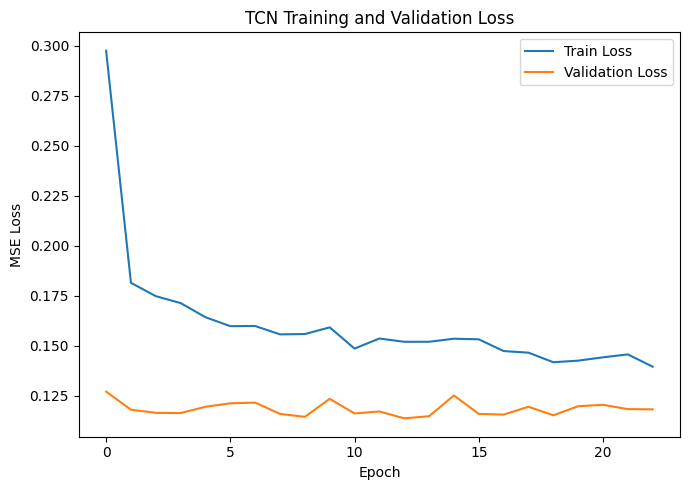

In [61]:
tcn_model.load_state_dict(
    best_state
)

tcn_model = tcn_model.to(
    device
)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    tcn_train_losses,
    label="Train Loss"
)

plt.plot(
    tcn_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "TCN Training and Validation Loss"
)

plt.legend()

plt.tight_layout()

plt.show()

In [62]:
y_pred_tcn_scaled, _ = predict_model(
    tcn_model,
    test_loader,
    device
)

y_pred_tcn = (
    y_scaler
    .inverse_transform(
        y_pred_tcn_scaled.reshape(-1, 1)
    )
    .flatten()
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

tcn_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tcn
    )
)

tcn_mae = mean_absolute_error(
    y_test,
    y_pred_tcn
)

tcn_r2 = r2_score(
    y_test,
    y_pred_tcn
)

tcn_bias = np.mean(
    y_pred_tcn - y_test
)

print(
    f"TCN RMSE : {tcn_rmse:.4f}"
)

print(
    f"TCN MAE  : {tcn_mae:.4f}"
)

print(
    f"TCN R²   : {tcn_r2:.4f}"
)

print(
    f"TCN Bias : {tcn_bias:.4f}"
)

TCN RMSE : 2.4003
TCN MAE  : 1.6926
TCN R²   : 0.9045
TCN Bias : 0.1681


### ode-lstm

In [63]:
MAX_LEN = 7

def build_ode_sequences(
    full_data,
    sample_data,
    exog_features,
    max_len=7
):
    sequences = []
    time_gaps = []
    sequence_lengths = []

    exogs = []
    targets = []

    patient_list = []
    index_dates = []

    patient_history = {
        pid: g.sort_values("visit_date").copy()
        for pid, g in full_data.groupby("patient_id")
    }

    for _, row in sample_data.iterrows():

        pid = row["patient_id"]
        index_date = row["visit_date"]

        history = patient_history[pid].copy()

        # 僅能使用 index date 當下或以前資料
        history = history[
            history["visit_date"] <= index_date
        ].copy()

        # MMSE 缺失的 observation 不參與 sequence
        history = history[
            history["mmse"].notna()
        ].copy()

        if len(history) == 0:
            continue

        # 最多取最近 7 次
        history = history.tail(max_len).copy()

        mmse_seq = (
            history["mmse"]
            .astype(float)
            .values
        )

        dates = pd.to_datetime(
            history["visit_date"]
        )

        # 相鄰 observation 時間差
        delta_days = (
            dates.diff()
            .dt.days
            .fillna(0)
            .values
            .astype(float)
        )

        # 改成年
        delta_years = (
            delta_days / 365.25
        )

        sequences.append(mmse_seq)
        time_gaps.append(delta_years)

        sequence_lengths.append(
            len(mmse_seq)
        )

        exogs.append(
            row[exog_features].values
        )

        targets.append(
            row["target_mmse_1y"]
        )

        patient_list.append(pid)
        index_dates.append(index_date)

    return (
        sequences,
        time_gaps,
        np.array(sequence_lengths),
        np.array(exogs, dtype=object),
        np.array(targets, dtype=float),
        np.array(patient_list),
        np.array(index_dates)
    )

In [ ]:
(
    train_ode_seq_raw,
    train_dt_raw,
    train_ode_lengths,
    X_train_ode_exog_raw,
    y_train_ode,
    train_ode_pid,
    train_ode_dates
) = build_ode_sequences(
    data,
    train_samples,
    exog_features,
    MAX_LEN
)


(
    val_ode_seq_raw,
    val_dt_raw,
    val_ode_lengths,
    X_val_ode_exog_raw,
    y_val_ode,
    val_ode_pid,
    val_ode_dates
) = build_ode_sequences(
    data,
    val_samples,
    exog_features,
    MAX_LEN
)


(
    test_ode_seq_raw,
    test_dt_raw,
    test_ode_lengths,
    X_test_ode_exog_raw,
    y_test_ode,
    test_ode_pid,
    test_ode_dates
) = build_ode_sequences(
    data,
    test_samples,
    exog_features,
    MAX_LEN
)

print("train:", len(train_ode_seq_raw))
print("val  :", len(val_ode_seq_raw))
print("test :", len(test_ode_seq_raw))

train: 2171
val  : 518
test : 504


In [67]:
def scale_pad_ode_sequences(
    sequences,
    time_gaps,
    scaler,
    max_len=7
):

    X_seq = np.zeros(
        (len(sequences), max_len, 1),
        dtype=np.float32
    )

    X_dt = np.zeros(
        (len(sequences), max_len),
        dtype=np.float32
    )

    lengths = []

    for i, (seq, dt) in enumerate(
        zip(sequences, time_gaps)
    ):

        seq = np.asarray(
            seq,
            dtype=float
        ).reshape(-1, 1)

        seq_scaled = (
            scaler.transform(seq)
            .flatten()
        )

        dt = np.asarray(
            dt,
            dtype=np.float32
        )

        length = len(seq_scaled)

        X_seq[
            i,
            :length,
            0
        ] = seq_scaled

        X_dt[
            i,
            :length
        ] = dt

        lengths.append(length)

    return (
        X_seq,
        X_dt,
        np.array(lengths)
    )

X_train_ode_seq, X_train_dt, train_ode_lengths = \
    scale_pad_ode_sequences(
        train_ode_seq_raw,
        train_dt_raw,
        mmse_scaler,
        MAX_LEN
    )

X_val_ode_seq, X_val_dt, val_ode_lengths = \
    scale_pad_ode_sequences(
        val_ode_seq_raw,
        val_dt_raw,
        mmse_scaler,
        MAX_LEN
    )

X_test_ode_seq, X_test_dt, test_ode_lengths = \
    scale_pad_ode_sequences(
        test_ode_seq_raw,
        test_dt_raw,
        mmse_scaler,
        MAX_LEN
    )

#Exogenous variables 也沿用原本 preprocessing
X_train_ode_exog_raw = (
    X_train_ode_exog_raw.astype(float)
)

X_val_ode_exog_raw = (
    X_val_ode_exog_raw.astype(float)
)

X_test_ode_exog_raw = (
    X_test_ode_exog_raw.astype(float)
)

#用你前面的 imputer
X_train_ode_exog = exog_imputer.transform(
    X_train_ode_exog_raw
)

X_val_ode_exog = exog_imputer.transform(
    X_val_ode_exog_raw
)

X_test_ode_exog = exog_imputer.transform(
    X_test_ode_exog_raw
)

#再用原本 scaler
X_train_ode_exog = exog_scaler.transform(
    X_train_ode_exog
)

X_val_ode_exog = exog_scaler.transform(
    X_val_ode_exog
)

X_test_ode_exog = exog_scaler.transform(
    X_test_ode_exog
)

#Target 也沿用
y_train_ode_scaled = (
    y_scaler.transform(
        y_train_ode.reshape(-1, 1)
    ).flatten()
)

y_val_ode_scaled = (
    y_scaler.transform(
        y_val_ode.reshape(-1, 1)
    ).flatten()
)

y_test_ode_scaled = (
    y_scaler.transform(
        y_test_ode.reshape(-1, 1)
    ).flatten()
)

In [69]:
#建立 ODE Dataset

class ODEMMSEDataset(Dataset):

    def __init__(
        self,
        X_seq,
        X_dt,
        lengths,
        X_exog,
        y
    ):

        self.X_seq = torch.tensor(
            X_seq,
            dtype=torch.float32
        )

        self.X_dt = torch.tensor(
            X_dt,
            dtype=torch.float32
        )

        self.lengths = torch.tensor(
            lengths,
            dtype=torch.long
        )

        self.X_exog = torch.tensor(
            X_exog,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):

        return (
            self.X_seq[idx],
            self.X_dt[idx],
            self.lengths[idx],
            self.X_exog[idx],
            self.y[idx]
        )

#dataloader
BATCH_SIZE = 32

train_ode_dataset = ODEMMSEDataset(
    X_train_ode_seq,
    X_train_dt,
    train_ode_lengths,
    X_train_ode_exog,
    y_train_ode_scaled
)

val_ode_dataset = ODEMMSEDataset(
    X_val_ode_seq,
    X_val_dt,
    val_ode_lengths,
    X_val_ode_exog,
    y_val_ode_scaled
)

test_ode_dataset = ODEMMSEDataset(
    X_test_ode_seq,
    X_test_dt,
    test_ode_lengths,
    X_test_ode_exog,
    y_test_ode_scaled
)

train_ode_loader = DataLoader(
    train_ode_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ode_loader = DataLoader(
    val_ode_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ode_loader = DataLoader(
    test_ode_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [70]:
class ODEFunc(nn.Module):

    def __init__(
        self,
        hidden_dim=64
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(
                hidden_dim,
                hidden_dim
            ),
            nn.Tanh(),

            nn.Linear(
                hidden_dim,
                hidden_dim
            )
        )

    def forward(self, h):

        return self.net(h)

#簡化式 ODE-LSTM
class ODELSTMClinicalModel(nn.Module):

    def __init__(
        self,
        exog_dim,
        hidden_dim=64,
        exog_hidden=64,
        fusion_hidden=64,
        dropout=0.2
    ):

        super().__init__()

        self.hidden_dim = hidden_dim

        # ====================================
        # Continuous-time ODE function
        # ====================================

        self.ode_func = ODEFunc(
            hidden_dim=hidden_dim
        )

        # ====================================
        # Observation update
        # ====================================

        self.lstm_cell = nn.LSTMCell(
            input_size=1,
            hidden_size=hidden_dim
        )

        # ====================================
        # Exogenous branch
        # ====================================

        self.exog_net = nn.Sequential(

            nn.Linear(
                exog_dim,
                exog_hidden
            ),

            nn.ReLU(),

            nn.Dropout(dropout)
        )

        # ====================================
        # Fusion
        # ====================================

        self.fusion = nn.Sequential(

            nn.Linear(
                hidden_dim + exog_hidden,
                fusion_hidden
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                fusion_hidden,
                1
            )
        )

    def forward(
        self,
        x_seq,
        delta_t,
        lengths,
        x_exog
    ):

        batch_size = x_seq.size(0)

        device = x_seq.device

        # initial states
        h = torch.zeros(
            batch_size,
            self.hidden_dim,
            device=device
        )

        c = torch.zeros(
            batch_size,
            self.hidden_dim,
            device=device
        )

        max_len = x_seq.size(1)

        for t in range(max_len):

            # 哪些 patient 在此 timestep 仍有效
            active = (
                t < lengths
            ).float().unsqueeze(1)

            dt = (
                delta_t[:, t]
                .unsqueeze(1)
            )

            # ======================================
            # 1. ODE evolution between observations
            # ======================================

            dh = self.ode_func(h)

            h_ode = (
                h + dt * dh
            )

            # ======================================
            # 2. LSTM observation update
            # ======================================

            x_t = x_seq[:, t, :]

            h_new, c_new = self.lstm_cell(
                x_t,
                (h_ode, c)
            )

            # padding timestep 不更新 state
            h = (
                active * h_new
                + (1 - active) * h
            )

            c = (
                active * c_new
                + (1 - active) * c
            )

        # ======================================
        # Clinical / exogenous branch
        # ======================================

        exog_feat = self.exog_net(
            x_exog
        )

        # ======================================
        # Fusion
        # ======================================

        fused = torch.cat(
            [
                h,
                exog_feat
            ],
            dim=1
        )

        output = self.fusion(
            fused
        )

        return output.squeeze(1)

In [71]:
ode_lstm_model = ODELSTMClinicalModel(

    exog_dim=X_train_ode_exog.shape[1],

    hidden_dim=64,

    exog_hidden=64,

    fusion_hidden=64,

    dropout=0.2

).to(device)

print(ode_lstm_model)

ODELSTMClinicalModel(
  (ode_func): ODEFunc(
    (net): Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )
  )
  (lstm_cell): LSTMCell(1, 64)
  (exog_net): Sequential(
    (0): Linear(in_features=27, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (fusion): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [73]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    ode_lstm_model.parameters(),
    lr=0.001
)

def train_ode_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    total_loss = 0.0

    for (
        x_seq,
        x_dt,
        lengths,
        x_exog,
        y
    ) in loader:

        x_seq = x_seq.to(device)
        x_dt = x_dt.to(device)
        lengths = lengths.to(device)
        x_exog = x_exog.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(
            x_seq,
            x_dt,
            lengths,
            x_exog
        )

        loss = criterion(
            pred,
            y
        )

        loss.backward()

        # ODE/RNN 建議限制 gradient
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        total_loss += (
            loss.item()
            * len(y)
        )

    return (
        total_loss
        / len(loader.dataset)
    )

def evaluate_ode_loss(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for (
            x_seq,
            x_dt,
            lengths,
            x_exog,
            y
        ) in loader:

            x_seq = x_seq.to(device)
            x_dt = x_dt.to(device)
            lengths = lengths.to(device)
            x_exog = x_exog.to(device)
            y = y.to(device)

            pred = model(
                x_seq,
                x_dt,
                lengths,
                x_exog
            )

            loss = criterion(
                pred,
                y
            )

            total_loss += (
                loss.item()
                * len(y)
            )

    return (
        total_loss
        / len(loader.dataset)
    )

In [74]:
MAX_EPOCHS = 100
PATIENCE = 10

best_val_loss = np.inf
best_state = None

patience_counter = 0

ode_train_losses = []
ode_val_losses = []

for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    train_loss = train_ode_epoch(
        ode_lstm_model,
        train_ode_loader,
        optimizer,
        criterion,
        device
    )

    val_loss = evaluate_ode_loss(
        ode_lstm_model,
        val_ode_loader,
        criterion,
        device
    )

    ode_train_losses.append(
        train_loss
    )

    ode_val_losses.append(
        val_loss
    )

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = {
            k: v.cpu().clone()
            for k, v
            in ode_lstm_model.state_dict().items()
        }

        patience_counter = 0

    else:

        patience_counter += 1

        if patience_counter >= PATIENCE:

            print("Early stopping.")

            break

ode_lstm_model.load_state_dict(
    best_state
)

ode_lstm_model = ode_lstm_model.to(
    device
)

Epoch 001 | Train Loss: 0.2957 | Val Loss: 0.1300
Epoch 002 | Train Loss: 0.1739 | Val Loss: 0.1246
Epoch 003 | Train Loss: 0.1555 | Val Loss: 0.1207
Epoch 004 | Train Loss: 0.1518 | Val Loss: 0.1223
Epoch 005 | Train Loss: 0.1487 | Val Loss: 0.1170
Epoch 006 | Train Loss: 0.1466 | Val Loss: 0.1165
Epoch 007 | Train Loss: 0.1387 | Val Loss: 0.1157
Epoch 008 | Train Loss: 0.1401 | Val Loss: 0.1184
Epoch 009 | Train Loss: 0.1393 | Val Loss: 0.1186
Epoch 010 | Train Loss: 0.1353 | Val Loss: 0.1133
Epoch 011 | Train Loss: 0.1348 | Val Loss: 0.1172
Epoch 012 | Train Loss: 0.1336 | Val Loss: 0.1161
Epoch 013 | Train Loss: 0.1347 | Val Loss: 0.1166
Epoch 014 | Train Loss: 0.1351 | Val Loss: 0.1149
Epoch 015 | Train Loss: 0.1329 | Val Loss: 0.1170
Epoch 016 | Train Loss: 0.1283 | Val Loss: 0.1179
Epoch 017 | Train Loss: 0.1300 | Val Loss: 0.1158
Epoch 018 | Train Loss: 0.1264 | Val Loss: 0.1160
Epoch 019 | Train Loss: 0.1227 | Val Loss: 0.1164
Epoch 020 | Train Loss: 0.1269 | Val Loss: 0.1156


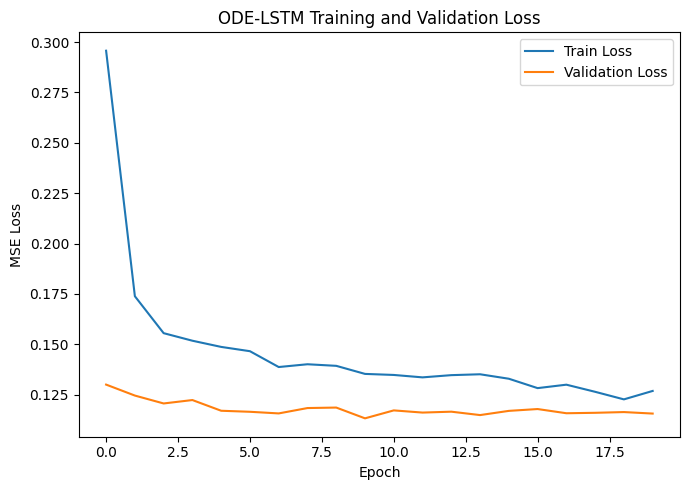

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    ode_train_losses,
    label="Train Loss"
)

plt.plot(
    ode_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "ODE-LSTM Training and Validation Loss"
)

plt.legend()

plt.tight_layout()

plt.show()

In [76]:
def predict_ode_model(
    model,
    loader,
    device
):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for (
            x_seq,
            x_dt,
            lengths,
            x_exog,
            y
        ) in loader:

            x_seq = x_seq.to(device)
            x_dt = x_dt.to(device)
            lengths = lengths.to(device)
            x_exog = x_exog.to(device)

            pred = model(
                x_seq,
                x_dt,
                lengths,
                x_exog
            )

            preds.extend(
                pred.cpu().numpy()
            )

            targets.extend(
                y.numpy()
            )

    return (
        np.array(preds),
        np.array(targets)
    )

y_pred_ode_scaled, _ = predict_ode_model(
    ode_lstm_model,
    test_ode_loader,
    device
)

y_pred_ode = (
    y_scaler.inverse_transform(
        y_pred_ode_scaled.reshape(-1, 1)
    )
    .flatten()
)

ode_rmse = np.sqrt(
    mean_squared_error(
        y_test_ode,
        y_pred_ode
    )
)

ode_mae = mean_absolute_error(
    y_test_ode,
    y_pred_ode
)

ode_r2 = r2_score(
    y_test_ode,
    y_pred_ode
)

ode_bias = np.mean(
    y_pred_ode - y_test_ode
)

print(
    f"ODE-LSTM RMSE : {ode_rmse:.4f}"
)

print(
    f"ODE-LSTM MAE  : {ode_mae:.4f}"
)

print(
    f"ODE-LSTM R²   : {ode_r2:.4f}"
)

print(
    f"ODE-LSTM Bias : {ode_bias:.4f}"
)

comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "XGBoost",
        "LSTM-NARX",
        "TCN",
        "ODE-LSTM"
    ],

    "RMSE": [
        2.6878,
        2.527761,
        2.4318,
        2.4003,
        ode_rmse
    ],

    "MAE": [
        1.8948,
        1.770394,
        1.7377,
        1.6926,
        ode_mae
    ],

    "R2": [
        0.8802,
        0.894042,
        0.9019,
        0.9045,
        ode_r2
    ],

    "Bias": [
        0.7877,
        0.132948,
        0.0967,
        0.1681,
        ode_bias
    ]
})

comparison

ODE-LSTM RMSE : 2.4559
ODE-LSTM MAE  : 1.7623
ODE-LSTM R²   : 0.9000
ODE-LSTM Bias : 0.1903


,Model,RMSE,MAE,R2,Bias
0,Naive,2.687800,1.894800,0.880200,0.787700
1,XGBoost,2.527761,1.770394,0.894042,0.132948
2,LSTM-NARX,2.431800,1.737700,0.901900,0.096700
3,TCN,2.400300,1.692600,0.904500,0.168100
4,ODE-LSTM,2.455895,1.762291,0.899981,0.190332
